In [1]:
import numpy as np
import matplotlib.pyplot as plt

def thomas_algorithm(a, b, c, d):
    n = len(b)
    for i in range(1, n):
        w = a[i] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) 
    
    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)

    for i in range(1, n - 1):
        A[i - 1] = h[i-1]
        B[i - 1] = 2 * (h[i-1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
        
    return A, B, C, D

def evaluate_spline(x, y, M, x_eval):
    n = len(x)
    h = np.diff(x)
    y_eval = []
    for val in x_eval:
        dx = np.searchsorted(x, val) - 1
        dx = max(0, min(dx, n - 2))
        
        hi = h[dx]
        b = val - x[dx]
        a = x[dx+1] - val
        
        s = (M[dx] * a**3 / (6*hi) + 
             M[dx+1] * b**3 / (6*hi) + 
             (y[dx]/h - M[dx]*hi/6) * a + 
             (y[dx+1]/hi - M[dx+1]*h/6) * b)
        y_eval.append(s)
    return np.array(y_eval)

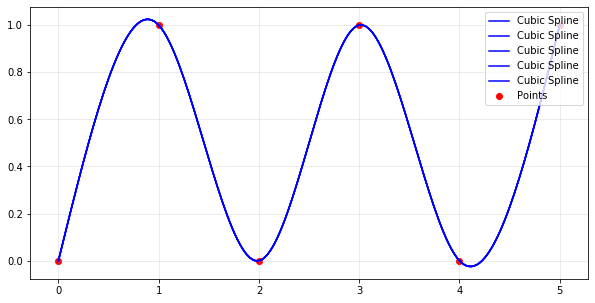

In [2]:
x_pts = np.array([0, 1, 2, 3, 4, 5])
y_pts = np.array([0, 1, 0, 1, 0, 1])

A, B, C, D = setup_tridiagonal_matrix(x_pts, y_pts)
M_internal = thomas_algorithm(A, B, C, D)

M = np.zeros(len(x_pts))
M[1:-1] = M_internal

x_fine = np.linspace(0, 5, 200)
y_fine = evaluate_spline(x_pts, y_pts, M, x_fine)

plt.figure(figsize=(10, 5))
plt.plot(x_fine, y_fine, label="Cubic Spline", color="b")
plt.scatter(x_pts, y_pts, color="r", label="Points")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()